# Tuning dropout parameters for ProtInt 
Tune the dropout weight for ProtInt

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import scanpy as sc
import matplotlib.pyplot as plt
from protint.projection import decode_matrix, load_model
from protint.model_cvae import BatchCVAEFeatureWiseDropout

In [ ]:
import yaml
with open("../../config/config.local.yaml", "r") as f:
    config = yaml.safe_load(f)
basedir = config['code_dir']

anndata_input_dir = os.path.join(config['output_data_dir'], 
                         "processed_proteomics_data", 
                         "1_1_9_ProCan_FDL_PanCancer_merged_tissue20.h5ad"
)  # where the tumor and cell line data, in anndata format, are stored

scratch_run_dir = os.path.join(config['output_data_dir'], "protint_tune_dropout_parameter")  # where the output of the protint model will be stored
if not os.path.exists(scratch_run_dir):
    os.makedirs(scratch_run_dir)

In [5]:
from Utils.helper_functions import reconstruct_with_original_batch
from Utils.plot_functions import joint_umap_original_reconstructed, plot_detected_reconstructed_imputed_histogram
from Utils.color_palette import tissue_palette, dropout_mode_colors

In [6]:

def load_loss_file(path, label):
    if not os.path.exists(path):
        print(f"⚠️ Warning: {label} file not found: {path}")
        return None
    df = pd.read_csv(path, sep="\t")
    if "epoch" not in df or "value" not in df:
        raise ValueError(f"File {path} requires 'epoch' & 'value' columns.")
    return df

## Plotting initial data

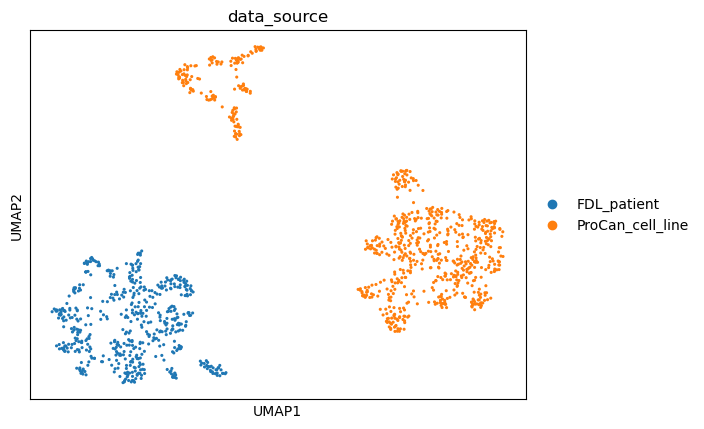

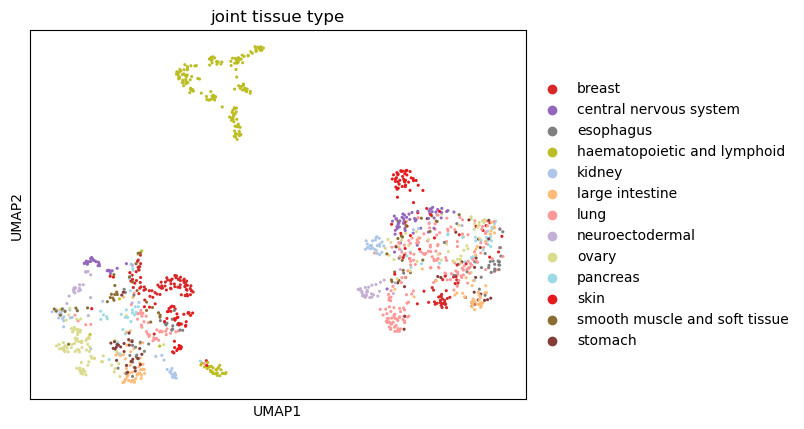

In [7]:
adata = sc.read_h5ad(anndata_input_dir)
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata, color="data_source", size=20)
sc.pl.umap(adata, color="joint tissue type", size=20, palette=tissue_palette)

## Tuning the dropout parameter on default model
Here the src_adv_weight is set to 0 and the dropout weight varied. The rho and zeta parameters were kept fixed. 

In [8]:
dropout_weights = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
seeds = [0, 1, 2, 3, 4]
result_fixed_dropout = []

loss_file = os.path.join(scratch_run_dir, "metrics", "train_loss_rec")

for dropout_weight in dropout_weights:
    for seed in seeds:
        print(f"Running with dropout_weight={dropout_weight}, seed={seed}")
        cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "3000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", str(dropout_weight),
            "--src_adv_weight", "0",
            "--cyc_weight", "0",
            "--output_dir", scratch_run_dir,
            "--random_seed", str(seed)
        ]
        result = subprocess.run(cmd, check=False)
        print("Return code:", result.returncode)

        # record training loss
        df_loss = load_loss_file(loss_file, "train_loss_rec")
        rec_loss = df_loss["value"].iloc[-1]   # endpoint only
        result_fixed_dropout.append({
                "seed": seed,
                "dropout_weight": dropout_weight,
                "reconstruction_loss": rec_loss,
            })
result_fixed_dropout_df = pd.DataFrame(result_fixed_dropout)

Running with dropout_weight=0, seed=0
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=1
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=2
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=3
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=4
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=0
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=1
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=2
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=3
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=4
Using device: cuda
Return code: 0
Running with dropout_weight=0.0001, seed=0
Using device: cuda
Return code: 0
Running with dropout_weight=0.0001, seed=1
Using device: cuda
Return code: 0
Running with dropout_weight=0.0001, seed=2
Using device: cuda
Return code: 0
Running with dropout_weight=0

## Tuning the dropout parameters on trainable dropout parameters
Here the src_adv_weight is set to 0 and the dropout weight varied. The rho and zeta parameters were set to be trainable by setting train_dropout. 

In [9]:
dropout_weights = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
seeds = [0, 1, 2, 3, 4]
result_trainable_dropout = []

loss_file = os.path.join(scratch_run_dir, "metrics", "train_loss_rec")

for dropout_weight in dropout_weights:
    for seed in seeds:
        print(f"Running with dropout_weight={dropout_weight}, seed={seed}")
        cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "3000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", str(dropout_weight),
            "--src_adv_weight", "0",
            "--cyc_weight", "0",
            "--output_dir", scratch_run_dir,
            "--random_seed", str(seed),
            "--train_dropout"
        ]
        result = subprocess.run(cmd, check=False)
        print("Return code:", result.returncode)

        # record training loss
        df_loss = load_loss_file(loss_file, "train_loss_rec")
        rec_loss = df_loss["value"].iloc[-1]   # endpoint only
        result_trainable_dropout.append({
                "seed": seed,
                "dropout_weight": dropout_weight,
                "reconstruction_loss": rec_loss,
            })
result_trainable_dropout_df = pd.DataFrame(result_trainable_dropout)

Running with dropout_weight=0, seed=0
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=1
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=2
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=3
Using device: cuda
Return code: 0
Running with dropout_weight=0, seed=4
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=0
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=1
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=2
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=3
Using device: cuda
Return code: 0
Running with dropout_weight=1e-05, seed=4
Using device: cuda
Return code: 0
Running with dropout_weight=0.0001, seed=0
Using device: cuda
Return code: 0
Running with dropout_weight=0.0001, seed=1
Using device: cuda
Return code: 0
Running with dropout_weight=0.0001, seed=2
Using device: cuda
Return code: 0
Running with dropout_weight=0

## Run an example of trainable dropout parameters

In [17]:
# run an example with the selected dropout weight to compare UMAP with the option when trainable dropout is on vs off
cmd = [
            "protint", "train",
            "--train_file", anndata_input_dir,
            "--hidden_dims", "128 64",
            "--encoding_dim", "32",
            "--batch_size", "512",
            "--epochs", "5000",
            "--batch_lr", "1e-3",
            "--src_adv_lr", "1e-3",
            "--kl_weight", "1e-6",
            "--dropout_weight", "0.1",
            "--src_adv_weight", "100",
            "--cyc_weight", "0",
            "--output_dir", scratch_run_dir,
            "--train_dropout"
        ]
result = subprocess.run(cmd, check=False)
print("Return code:", result.returncode)

Using device: cuda
Return code: 0


In [18]:
cmd = [
    "protint", "projection",
    "--projection_file", anndata_input_dir,
    "--model_dir", os.path.join(scratch_run_dir, "models"),
    "--onto", "FDL_patient",
    "--output_file", os.path.join(scratch_run_dir, "projection.h5ad"),
]

result = subprocess.run(cmd, check=False)

print("Return code:", result.returncode)

Loaded model epoch: 4999, loss 2206.1314818319456
Return code: 0


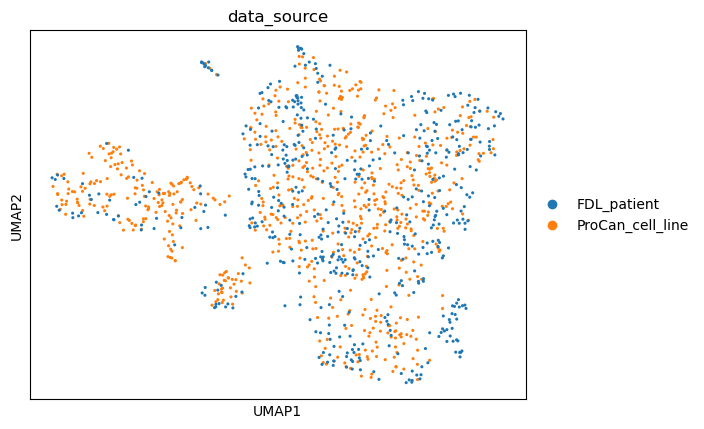

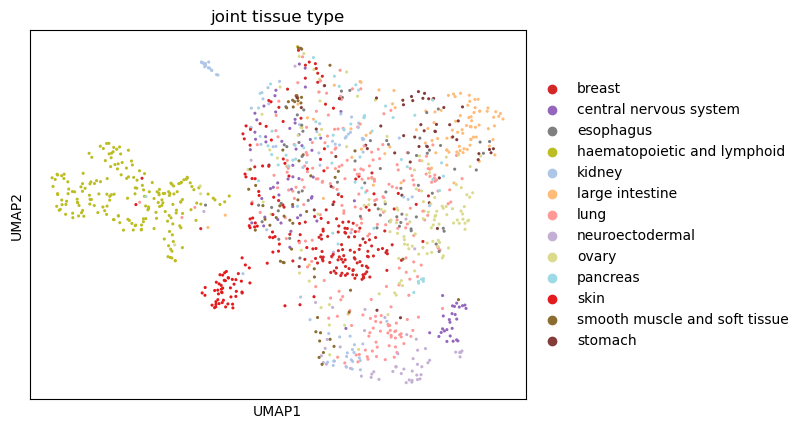

In [19]:
# import the projected data and visualize
adata_projected = sc.read_h5ad(os.path.join(scratch_run_dir, "projection.h5ad"))

# Copy harmonized color palette
adata_projected.uns["joint tissue type_colors"] = adata.uns["joint tissue type_colors"].copy()
# quick umap of the adata
# Use the imputed layer as the working matrix
sc.pp.pca(adata_projected, n_comps=50, mask_var=None)

# Build neighbor graph from the PCA representation computed above
sc.pp.neighbors(adata_projected, n_neighbors=15, n_pcs=50, use_rep="X_pca")

# UMAP with your settings
sc.tl.umap(adata_projected, min_dist=0.5)

# (Optional) quick plot
sc.pl.umap(adata_projected, color="data_source", size=20)
sc.pl.umap(adata_projected, color="joint tissue type", size=20, palette=tissue_palette)

In [20]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, features, label_encode = load_model(
    os.path.join(scratch_run_dir, "models"),
    device,
    model_cls=BatchCVAEFeatureWiseDropout,
)
# Important: same feature order as training/model
adata = adata[:, features].copy()

recon_adata, z_adata = reconstruct_with_original_batch(
    model=model,
    adata=adata,
    label_encode=label_encode,
    decode_matrix=decode_matrix,
    batch_key="data_source",   # replace with your adata.obs column
    device=device,
    decimals=4,
    batch_size=1600,
)

Loaded model epoch: 4999, loss 2206.1314818319456


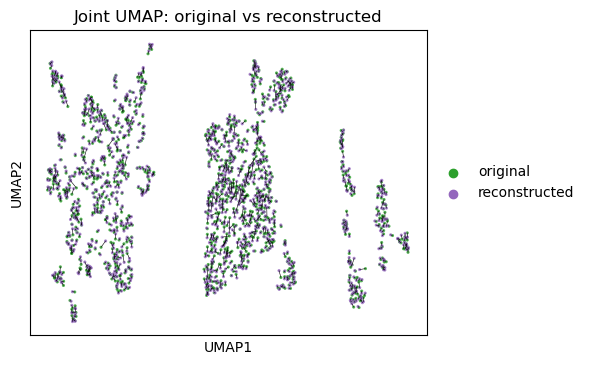

In [21]:
joint, fig, ax = joint_umap_original_reconstructed(
    adata,
    recon_adata,
    detected_layer="detected"
)

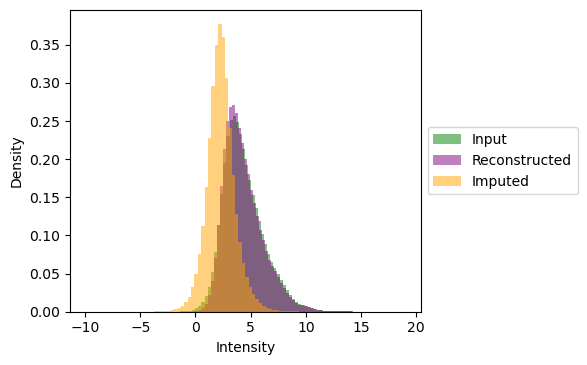

In [22]:
plot_detected_reconstructed_imputed_histogram(
    adata,
    recon_adata,
    figsize=(6,3.75))

## Compare the reconstruction loss 

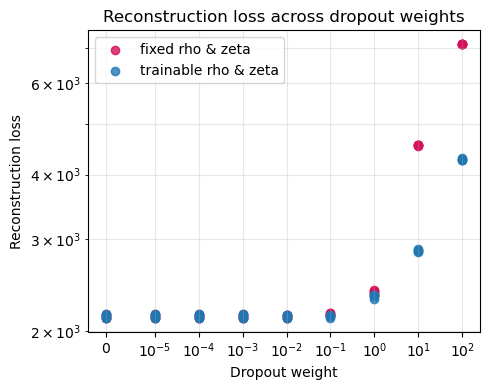

In [23]:
fixed_df = result_fixed_dropout_df.copy()
fixed_df["mode"] = "fixed rho & zeta"

trainable_df = result_trainable_dropout_df.copy()
trainable_df["mode"] = "trainable rho & zeta"

plot_df = pd.concat([fixed_df, trainable_df], ignore_index=True)

plt.figure(figsize=(5, 4))

for mode, df_mode in plot_df.groupby("mode"):
    df_mode = df_mode.sort_values("dropout_weight")

    plt.scatter(
        df_mode["dropout_weight"],
        df_mode["reconstruction_loss"],
        alpha=0.8,
        label=mode,
        color=dropout_mode_colors[mode]
    )

plt.xscale("symlog", linthresh=1e-5)
plt.yscale("log")

plt.xlabel("Dropout weight")
plt.ylabel("Reconstruction loss")
plt.title("Reconstruction loss across dropout weights")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()